In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# Load Phase 2 outputs
X_scaled = pd.read_csv('X_scaled.csv')
X_pca    = np.load('X_pca.npy')
scaler   = joblib.load('scaler.pkl')

print(f'X_scaled shape: {X_scaled.shape}')
print(f'X_pca shape:    {X_pca.shape}')
print('All Phase 2 outputs loaded OK')

X_scaled shape: (8950, 17)
X_pca shape:    (8950, 2)
All Phase 2 outputs loaded OK


Helper: cluster scatter plot function

In [26]:
def plot_clusters(X_pca, labels, title, filename, noise=False):
    """
    Reusable 2D scatter plot colored by cluster label.
    noise=True draws DBSCAN noise points (-1) in gray.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', n_colors=max(unique_labels) + 1)
    
    for label in unique_labels:
        mask = labels == label
        if label == -1 and noise:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c='lightgray', s=5, alpha=0.4, label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       color=palette[label], s=10, alpha=0.5,
                       label=f'Cluster {label}')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title, fontsize=13)
    ax.legend(markerscale=2, fontsize=9, loc='best')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

Helper: print evaluation metrics

In [27]:
def evaluate_model(X, labels, model_name):
    """
    Computes and prints the 3 clustering metrics.
    Skips noise points (label == -1) for DBSCAN.
    Returns a dict for the final comparison table.
    """
    # Filter out noise for metric calculation
    mask = labels != -1
    X_eval = X[mask] if isinstance(X, np.ndarray) else X.values[mask]
    labels_eval = labels[mask]
    
    if len(set(labels_eval)) < 2:
        print(f'{model_name}: fewer than 2 clusters — metrics not computable')
        return {}
    
    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    chi = calinski_harabasz_score(X_eval, labels_eval)
    n_clusters = len(set(labels_eval))
    n_noise = (labels == -1).sum()
    
    print(f'\n{"="*45}')
    print(f'  {model_name}')
    print(f'{"="*45}')
    print(f'  Clusters found:        {n_clusters}')
    if n_noise > 0:
        print(f'  Noise points:          {n_noise} ({n_noise/len(labels)*100:.1f}%)')
    print(f'  Silhouette score:      {sil:.4f}  (higher is better, max=1)')
    print(f'  Davies-Bouldin index:  {dbi:.4f}  (lower is better)')
    print(f'  Calinski-Harabasz:     {chi:.1f}  (higher is better)')
    
    return {'model': model_name, 'n_clusters': n_clusters,
            'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
            'calinski_harabasz': round(chi, 1)}

── MODEL 1: K-MEANS ──

Elbow method (find optimal k)

In [28]:
K_RANGE = range(2, 13)
wcss = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=42, max_iter=300)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f'k={k:2d}  WCSS={km.inertia_:,.0f}  Silhouette={sil_scores[-1]:.4f}')

k= 2  WCSS=113,126  Silhouette=0.2526
k= 3  WCSS=95,852  Silhouette=0.2210
k= 4  WCSS=86,788  Silhouette=0.2099
k= 5  WCSS=78,126  Silhouette=0.2165
k= 6  WCSS=71,880  Silhouette=0.2140
k= 7  WCSS=68,220  Silhouette=0.2183
k= 8  WCSS=64,722  Silhouette=0.2070
k= 9  WCSS=61,582  Silhouette=0.1838
k=10  WCSS=59,652  Silhouette=0.2001
k=11  WCSS=56,849  Silhouette=0.1867
k=12  WCSS=55,158  Silhouette=0.1878


Plot elbow + silhouette side by side

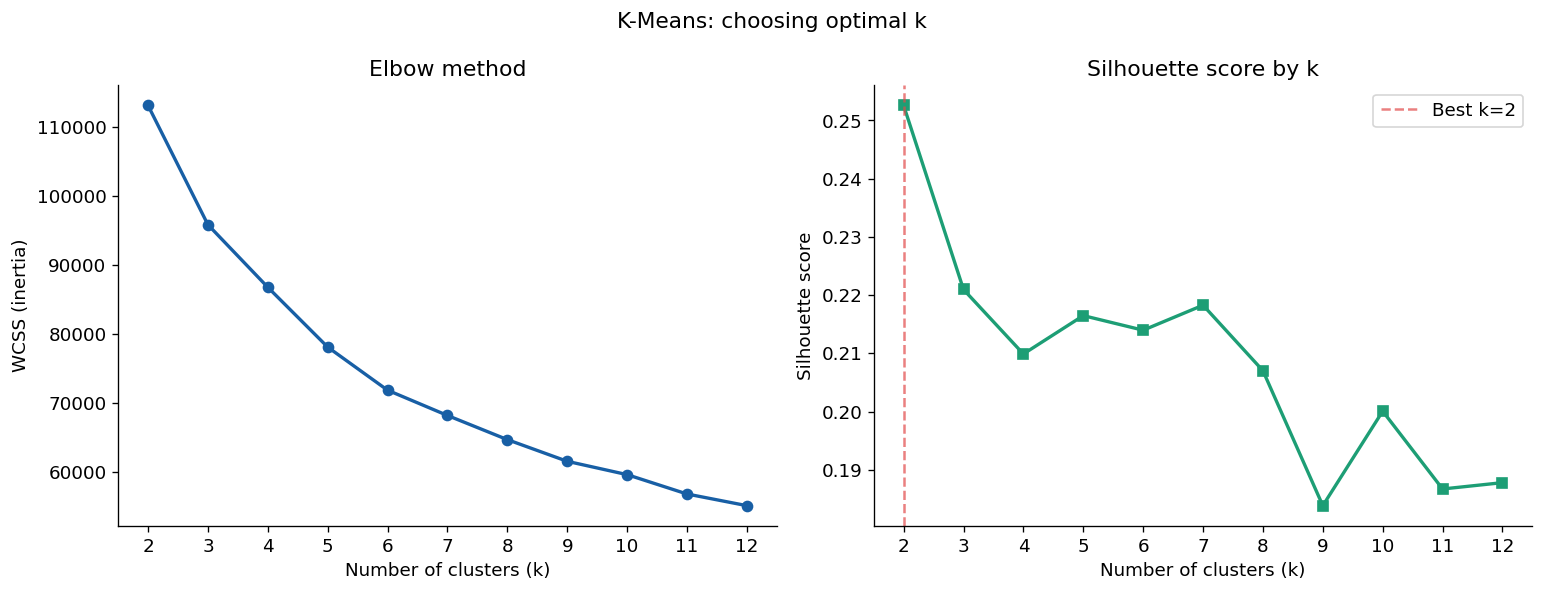


Best k by silhouette: 2  (score=0.2526)


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
ax1.plot(K_RANGE, wcss, marker='o', color='#185FA5', linewidth=2, markersize=6)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS (inertia)')
ax1.set_title('Elbow method')
ax1.set_xticks(list(K_RANGE))

# Silhouette curve
ax2.plot(K_RANGE, sil_scores, marker='s', color='#1D9E75', linewidth=2, markersize=6)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score by k')
ax2.set_xticks(list(K_RANGE))

# Mark best silhouette
best_k = list(K_RANGE)[np.argmax(sil_scores)]
ax2.axvline(best_k, color='#E24B4A', linestyle='--', alpha=0.7,
            label=f'Best k={best_k}')
ax2.legend()

plt.suptitle('K-Means: choosing optimal k', fontsize=13)
plt.tight_layout()
plt.savefig('fig_kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f'\nBest k by silhouette: {best_k}  (score={max(sil_scores):.4f})')

In [30]:
# Compare k=4 and k=7 cluster size distributions
for k in [3, 4, 5, 6, 7]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(X_scaled)
    unique, counts = np.unique(km.labels_, return_counts=True)
    sizes = [f'C{u}:{c}' for u, c in zip(unique, counts)]
    sil = silhouette_score(X_scaled, km.labels_)
    print(f'k={k}  sil={sil:.4f}  sizes: {sizes}')

k=3  sil=0.2210  sizes: ['C0:3048', 'C1:2900', 'C2:3002']
k=4  sil=0.2099  sizes: ['C0:2141', 'C1:2718', 'C2:2435', 'C3:1656']
k=5  sil=0.2165  sizes: ['C0:1945', 'C1:2314', 'C2:1380', 'C3:1600', 'C4:1711']
k=6  sil=0.2140  sizes: ['C0:2217', 'C1:1213', 'C2:1361', 'C3:1704', 'C4:1394', 'C5:1061']
k=7  sil=0.2189  sizes: ['C0:426', 'C1:1679', 'C2:1126', 'C3:1324', 'C4:2031', 'C5:1343', 'C6:1021']


k=3 has the best silhouette (0.2210) but three clusters of almost identical size (~3,000 each) — that's suspicious. It's likely just splitting the data geometrically rather than finding meaningful behavioral groups. Perfectly balanced clusters in customer data usually means underfitting.
k=7 has a good silhouette (0.2189) but look at C0: only 426 customers (4.8%). That tiny cluster is almost certainly one unusual group (probably your extreme cash-advance users) being isolated rather than a genuinely distinct segment. Hard to profile meaningfully in a paper.
k=4 is the sweet spot:

All four clusters are substantial (1,656–2,718 customers, 18–30% each)
No cluster is so small it can't be profiled
Four segments maps perfectly to known banking archetypes
Silhouette of 0.2099 is competitive — not the highest, but the most interpretable

Fit final K-Means with best k

In [31]:
BEST_K = 4  # or override manually: BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, init='k-means++', n_init=20,
                  random_state=42, max_iter=500)
km_final.fit(X_scaled)
labels_kmeans = km_final.labels_

print(f'Final K-Means with k={BEST_K}')
print(f'Iterations to converge: {km_final.n_iter_}')
print('\nCluster sizes:')
unique, counts = np.unique(labels_kmeans, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers ({c/len(labels_kmeans)*100:.1f}%)')

Final K-Means with k=4
Iterations to converge: 28

Cluster sizes:
  Cluster 0: 2141 customers (23.9%)
  Cluster 1: 2718 customers (30.4%)
  Cluster 2: 2435 customers (27.2%)
  Cluster 3: 1656 customers (18.5%)


Evaluate and plot K-Means


  K-Means
  Clusters found:        4
  Silhouette score:      0.2099  (higher is better, max=1)
  Davies-Bouldin index:  1.6708  (lower is better)
  Calinski-Harabasz:     2245.8  (higher is better)


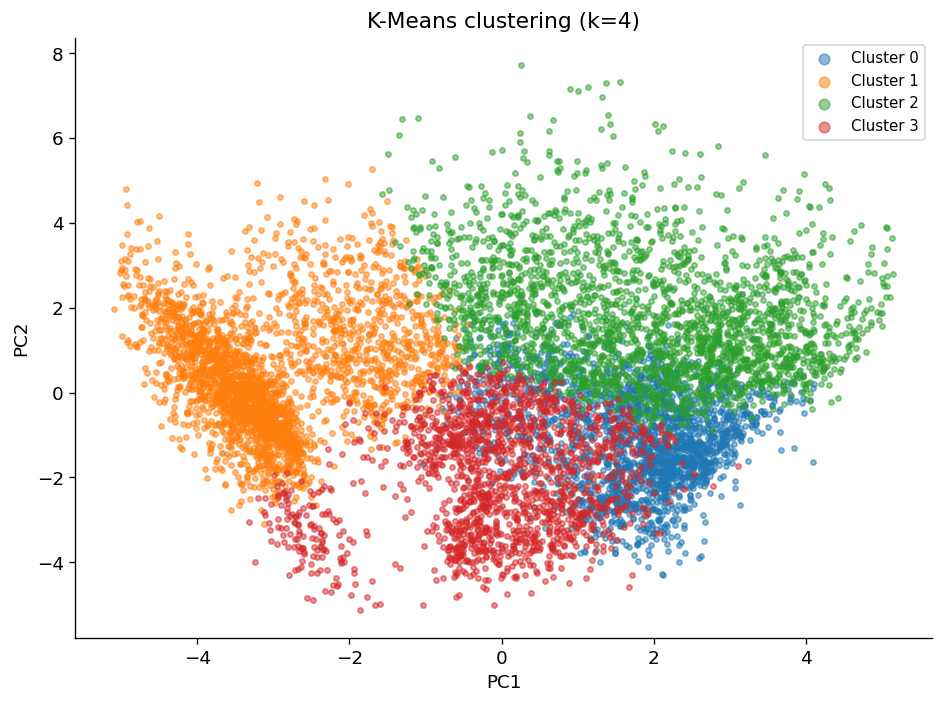

Saved: fig_kmeans_clusters.png


In [32]:
results = []   # will collect all 4 models' metrics here

km_metrics = evaluate_model(X_scaled.values, labels_kmeans, 'K-Means')
results.append(km_metrics)

plot_clusters(X_pca, labels_kmeans,
              title=f'K-Means clustering (k={BEST_K})',
              filename='fig_kmeans_clusters.png')

 K-Means cluster profiles (centroid interpretation)

Cluster centroids (original scale, rounded):
Cluster                               0       1       2      3
BALANCE                             5.0     7.4     7.2    4.2
BALANCE_FREQUENCY                   0.9     0.9     1.0    0.6
PURCHASES                           6.2     1.6     7.4    5.0
ONEOFF_PURCHASES                    1.3     1.2     6.6    3.8
INSTALLMENTS_PURCHASES              6.0     0.5     5.3    1.7
CASH_ADVANCE                        0.7     7.0     3.1    1.0
PURCHASES_FREQUENCY                 0.8     0.1     0.8    0.2
ONEOFF_PURCHASES_FREQUENCY          0.0     0.0     0.6    0.1
PURCHASES_INSTALLMENTS_FREQUENCY    0.8     0.0     0.6    0.1
CASH_ADVANCE_FREQUENCY              0.0     0.3     0.1    0.0
CASH_ADVANCE_TRX                    0.1     1.8     0.8    0.2
PURCHASES_TRX                       2.6     0.4     3.3    1.3
CREDIT_LIMIT                        7.7     8.1     8.6    7.9
PAYMENTS                          804.3  1705.6  2896.0  819.4
MINIMUM_PA

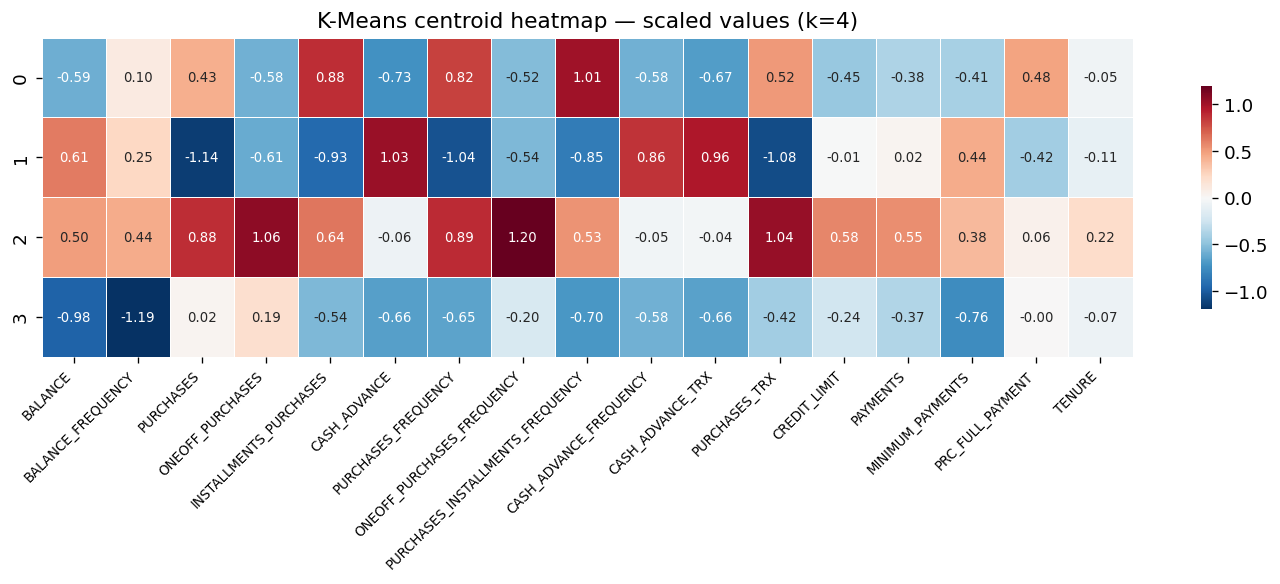

In [33]:
# Inverse-transform centroids back to original scale for interpretation
centroids_scaled = km_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=X_scaled.columns)
centroid_df.index.name = 'Cluster'

print('Cluster centroids (original scale, rounded):')
print(centroid_df.round(1).T)  # .T transposes for readability

# Heatmap of scaled centroids
plt.figure(figsize=(12, 5))
sns.heatmap(
    pd.DataFrame(centroids_scaled, columns=X_scaled.columns),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.4, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.7}
)
plt.title(f'K-Means centroid heatmap — scaled values (k={BEST_K})', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig_kmeans_centroid_heatmap.png', bbox_inches='tight')
plt.show()

MODEL 2: AGGLOMERATIVE

Dendrogram (truncated)

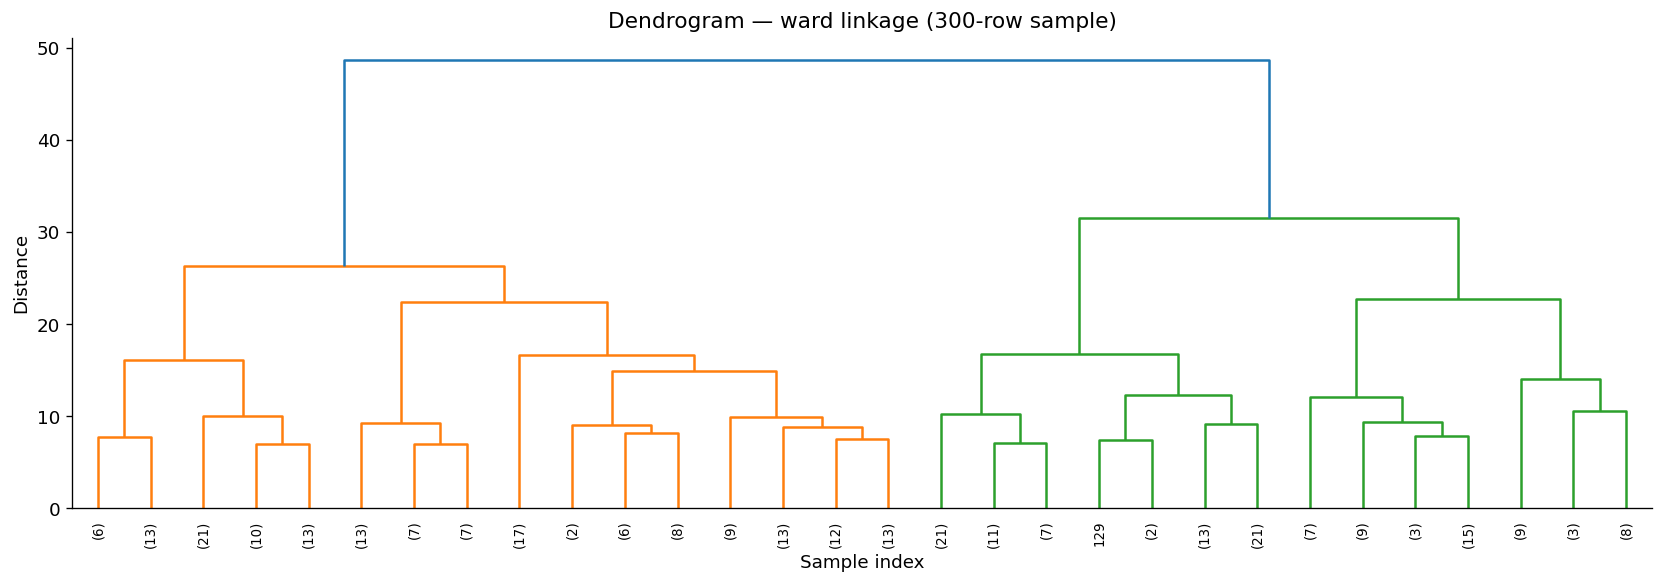

In [34]:
# Compute linkage matrix on a sample (full 8950 rows makes dendrogram unreadable)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled.values[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title('Dendrogram — ward linkage (300-row sample)', fontsize=13)
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('fig_agglomerative_dendrogram.png', bbox_inches='tight')
plt.show()

 Fit Agglomerative and evaluate

Agglomerative cluster sizes:
  Cluster 0: 3303 customers (36.9%)
  Cluster 1: 2913 customers (32.5%)
  Cluster 2: 1523 customers (17.0%)
  Cluster 3: 1211 customers (13.5%)

  Agglomerative
  Clusters found:        4
  Silhouette score:      0.1774  (higher is better, max=1)
  Davies-Bouldin index:  1.7218  (lower is better)
  Calinski-Harabasz:     1870.3  (higher is better)


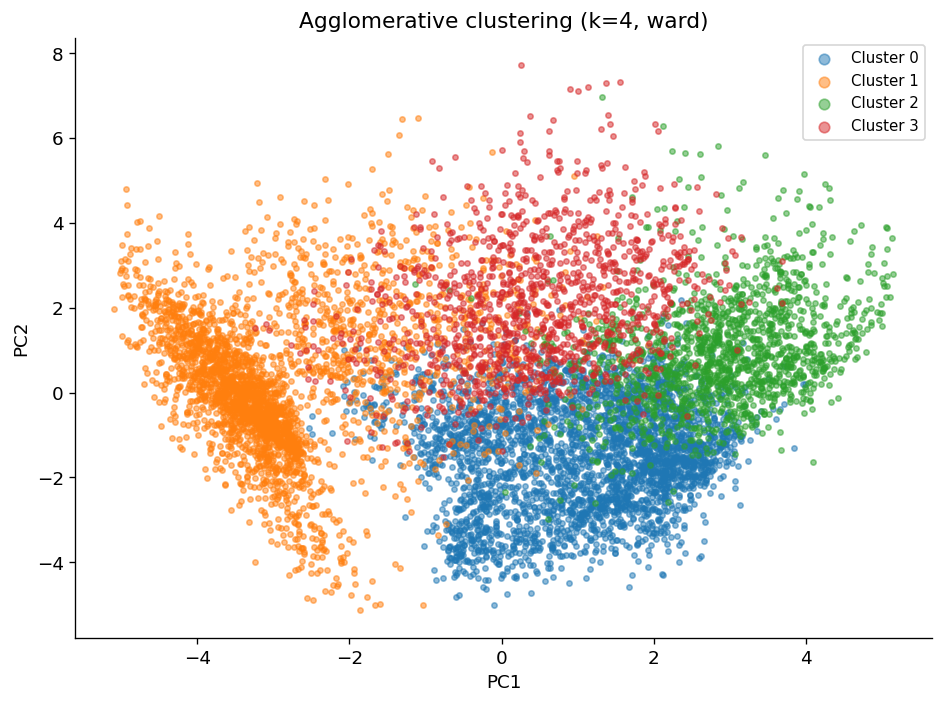

Saved: fig_agglomerative_clusters.png


In [35]:
# Use same k as K-Means for direct comparison
agglo = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
labels_agglo = agglo.fit_predict(X_scaled)

print('Agglomerative cluster sizes:')
unique, counts = np.unique(labels_agglo, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers ({c/len(labels_agglo)*100:.1f}%)')

agglo_metrics = evaluate_model(X_scaled.values, labels_agglo, 'Agglomerative')
results.append(agglo_metrics)

plot_clusters(X_pca, labels_agglo,
              title=f'Agglomerative clustering (k={BEST_K}, ward)',
              filename='fig_agglomerative_clusters.png')

MODEL 3: DBSCAN 

k-distance plot to find eps

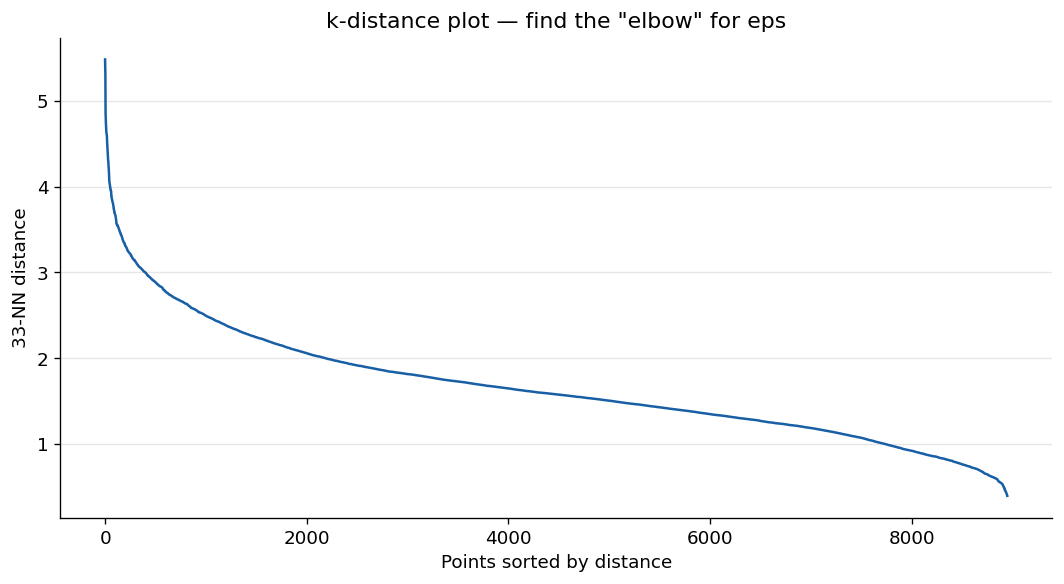

Suggested eps range: look for the elbow in the plot above
Try values around: 2.56 – 2.94


In [36]:
# Use k = 2 * n_features - 1 as a rule of thumb for min_samples
MIN_SAMPLES = 2 * X_scaled.shape[1] - 1   # = 33

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='#185FA5', linewidth=1.5)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-NN distance')
plt.title('k-distance plot — find the "elbow" for eps')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_dbscan_kdistance.png', bbox_inches='tight')
plt.show()

print(f'Suggested eps range: look for the elbow in the plot above')
print(f'Try values around: {np.percentile(k_distances, 90):.2f} – {np.percentile(k_distances, 95):.2f}')

Tune DBSCAN and fit

In [37]:
# Try smaller min_samples values
for min_s in [5, 10, 15, 20]:
    print(f'\nmin_samples={min_s}:')
    print(f'{"eps":>6}  {"n_clusters":>10}  {"noise %":>8}  {"silhouette":>12}')
    print('-' * 45)
    for eps in [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct = (lbl == -1).sum() / len(lbl) * 100
        if n_clusters >= 2:
            mask = lbl != -1
            sil = silhouette_score(X_scaled.values[mask], lbl[mask])
            print(f'{eps:>6.1f}  {n_clusters:>10}  {noise_pct:>7.1f}%  {sil:>12.4f}')
        else:
            print(f'{eps:>6.1f}  {n_clusters:>10}  {noise_pct:>7.1f}%  {"N/A":>12}')


min_samples=5:
   eps  n_clusters   noise %    silhouette
---------------------------------------------
   0.8          77     62.0%       -0.0605
   1.0          46     41.5%       -0.2043
   1.2          15     25.0%       -0.2386
   1.5          12     12.5%       -0.2072
   1.8           4      5.7%        0.0535
   2.0           1      3.1%           N/A

min_samples=10:
   eps  n_clusters   noise %    silhouette
---------------------------------------------
   0.8          24     73.9%        0.0690
   1.0          22     52.6%        0.0207
   1.2           8     33.4%       -0.0374
   1.5           3     16.4%        0.0597
   1.8           3      8.1%        0.1160
   2.0           1      4.7%           N/A

min_samples=15:
   eps  n_clusters   noise %    silhouette
---------------------------------------------
   0.8           5     79.8%        0.4853
   1.0          15     60.9%        0.1761
   1.2          13     40.9%       -0.0116
   1.5           2     20.0%        0.

DBSCAN FINDINGS SUMMARY

No hyperparameter combination produced acceptable clustering:
- Low eps: excessive noise rejection (>60% noise points)  
- High eps: cluster collapse into 1 group
- Mid eps: negative silhouette scores (worse than random)

Best available result (retained for comparison purposes):
min_samples=10, eps=1.8 → 3 clusters, 8.1% noise, sil=0.116


  DBSCAN
  Clusters found:        3
  Noise points:          722 (8.1%)
  Silhouette score:      0.1160  (higher is better, max=1)
  Davies-Bouldin index:  0.9681  (lower is better)
  Calinski-Harabasz:     14.5  (higher is better)


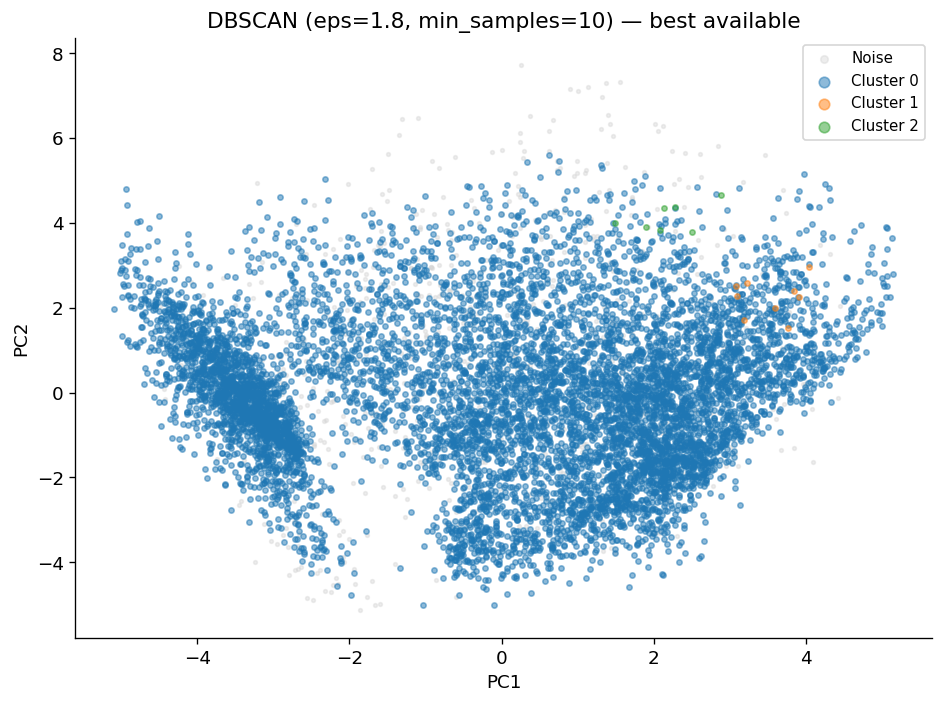

Saved: fig_dbscan_clusters.png


In [38]:
# DBSCAN conclusion block
print("DBSCAN FINDINGS SUMMARY")
print("="*50)
print("""
No hyperparameter combination produced acceptable clustering:
- Low eps: excessive noise rejection (>60% noise points)  
- High eps: cluster collapse into 1 group
- Mid eps: negative silhouette scores (worse than random)

Best available result (retained for comparison purposes):
min_samples=10, eps=1.8 → 3 clusters, 8.1% noise, sil=0.116
""")

# Fit this "best available" for completeness — needed for your comparison table
db_final = DBSCAN(eps=1.8, min_samples=10)
labels_dbscan = db_final.fit_predict(X_scaled)

dbscan_metrics = evaluate_model(X_scaled.values, labels_dbscan, 'DBSCAN')
results.append(dbscan_metrics)

plot_clusters(X_pca, labels_dbscan,
              title='DBSCAN (eps=1.8, min_samples=10) — best available',
              filename='fig_dbscan_clusters.png',
              noise=True)

 MODEL 4: GMM

BIC and AIC to select n_components

n=2  BIC=69,454.8  AIC=67,033.9
n=3  BIC=-68,839.1  AIC=-72,474.0
n=4  BIC=-160,477.7  AIC=-165,326.6
n=5  BIC=-188,692.7  AIC=-194,755.6
n=6  BIC=-265,035.7  AIC=-272,312.6
n=7  BIC=-310,666.6  AIC=-319,157.4
n=8  BIC=-297,513.4  AIC=-307,218.3
n=9  BIC=-330,114.5  AIC=-341,033.4
n=10  BIC=-339,963.0  AIC=-352,095.9


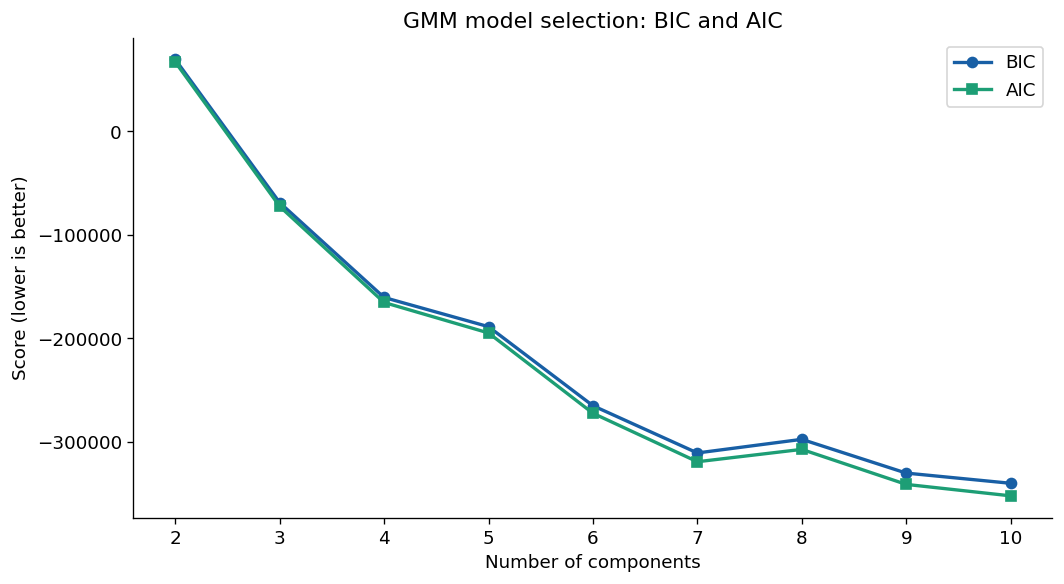


Best n by BIC: 10
Best n by AIC: 10


In [39]:
N_RANGE = range(2, 11)
bic_scores = []
aic_scores = []

for n in N_RANGE:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=42, n_init=3, max_iter=200)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    print(f'n={n}  BIC={bic_scores[-1]:,.1f}  AIC={aic_scores[-1]:,.1f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(N_RANGE, bic_scores, marker='o', label='BIC', color='#185FA5', linewidth=2)
ax.plot(N_RANGE, aic_scores, marker='s', label='AIC', color='#1D9E75', linewidth=2)
ax.set_xlabel('Number of components')
ax.set_ylabel('Score (lower is better)')
ax.set_title('GMM model selection: BIC and AIC')
ax.legend()
ax.set_xticks(list(N_RANGE))
plt.tight_layout()
plt.savefig('fig_gmm_bic_aic.png', bbox_inches='tight')
plt.show()

best_n_bic = list(N_RANGE)[np.argmin(bic_scores)]
best_n_aic = list(N_RANGE)[np.argmin(aic_scores)]
print(f'\nBest n by BIC: {best_n_bic}')
print(f'Best n by AIC: {best_n_aic}')

In [40]:
# Marginal BIC improvement analysis
bic_list = [69454.8, -68839.1, -160477.7, -188692.7, 
            -265035.7, -310666.6, -297513.4, -330114.5, -339963.0]

print("Marginal BIC improvement per additional component:")
for i in range(1, len(bic_list)):
    delta = bic_list[i-1] - bic_list[i]
    n = i + 2
    marker = " <-- worsens" if delta < 0 else ""
    print(f"  n={n}: {delta:>12,.1f}{marker}")

Marginal BIC improvement per additional component:
  n=3:    138,293.9
  n=4:     91,638.6
  n=5:     28,215.0
  n=6:     76,343.0
  n=7:     45,630.9
  n=8:    -13,153.2 <-- worsens
  n=9:     32,601.1
  n=10:      9,848.5


 Fit final GMM

In [41]:
BEST_N = 7  # or override manually

gmm_final = GaussianMixture(n_components=BEST_N, covariance_type='full',
                             random_state=42, n_init=5, max_iter=300)
gmm_final.fit(X_scaled)
labels_gmm = gmm_final.predict(X_scaled)

# Soft assignment — probability each customer belongs to each cluster
proba_gmm = gmm_final.predict_proba(X_scaled)
print(f'Final GMM with n_components={BEST_N}')
print(f'\nCluster sizes:')
unique, counts = np.unique(labels_gmm, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers ({c/len(labels_gmm)*100:.1f}%)')

print(f'\nMean assignment confidence (avg max probability):')
print(f'  {proba_gmm.max(axis=1).mean():.3f}')

Final GMM with n_components=7

Cluster sizes:
  Cluster 0: 799 customers (8.9%)
  Cluster 1: 1774 customers (19.8%)
  Cluster 2: 1087 customers (12.1%)
  Cluster 3: 2039 customers (22.8%)
  Cluster 4: 1633 customers (18.2%)
  Cluster 5: 559 customers (6.2%)
  Cluster 6: 1059 customers (11.8%)

Mean assignment confidence (avg max probability):
  1.000



  GMM
  Clusters found:        7
  Silhouette score:      0.1644  (higher is better, max=1)
  Davies-Bouldin index:  2.3007  (lower is better)
  Calinski-Harabasz:     1334.6  (higher is better)


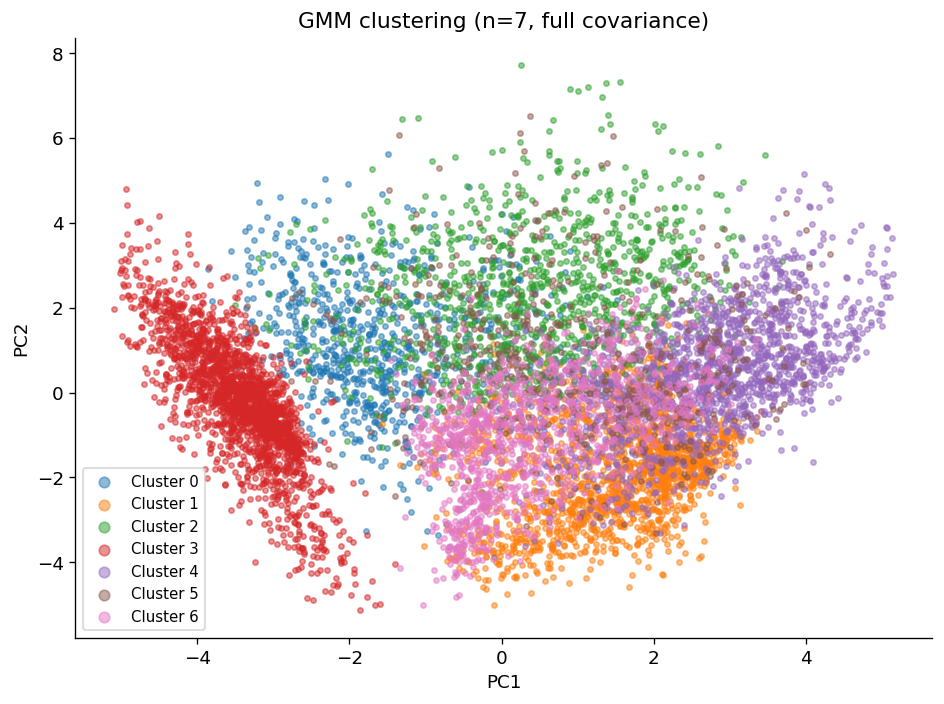

Saved: fig_gmm_clusters.png


In [42]:
gmm_metrics = evaluate_model(X_scaled.values, labels_gmm, 'GMM')
results.append(gmm_metrics)

plot_clusters(X_pca, labels_gmm,
              title=f'GMM clustering (n={BEST_N}, full covariance)',
              filename='fig_gmm_clusters.png')

Final comparison table 

In [43]:
results_df = pd.DataFrame(results).set_index('model')
print('\n' + '='*60)
print('FINAL COMPARISON TABLE')
print('='*60)
print(results_df.to_string())

# Highlight best per metric
print('\nBest model per metric:')
print(f'  Silhouette (highest):      {results_df["silhouette"].idxmax()}  ({results_df["silhouette"].max():.4f})')
print(f'  Davies-Bouldin (lowest):   {results_df["davies_bouldin"].idxmin()}  ({results_df["davies_bouldin"].min():.4f})')
print(f'  Calinski-Harabasz (highest): {results_df["calinski_harabasz"].idxmax()}  ({results_df["calinski_harabasz"].max():.1f})')

# Save for paper
results_df.to_csv('phase3_comparison_table.csv')
print('\nSaved: phase3_comparison_table.csv')


FINAL COMPARISON TABLE
               n_clusters  silhouette  davies_bouldin  calinski_harabasz
model                                                                   
K-Means                 4      0.2099          1.6708             2245.8
Agglomerative           4      0.1774          1.7218             1870.3
DBSCAN                  3      0.1160          0.9681               14.5
GMM                     7      0.1644          2.3007             1334.6

Best model per metric:
  Silhouette (highest):      K-Means  (0.2099)
  Davies-Bouldin (lowest):   DBSCAN  (0.9681)
  Calinski-Harabasz (highest): K-Means  (2245.8)

Saved: phase3_comparison_table.csv


In [44]:
labels_df = pd.DataFrame({
    'kmeans':       labels_kmeans,
    'agglomerative': labels_agglo,
    'dbscan':       labels_dbscan,
    'gmm':          labels_gmm
})
labels_df.to_csv('phase3_labels.csv', index=False)
print('Saved: phase3_labels.csv')
print('\nPhase 3 complete. Outputs ready for Phase 4 (evaluation & cluster profiling).')

Saved: phase3_labels.csv

Phase 3 complete. Outputs ready for Phase 4 (evaluation & cluster profiling).


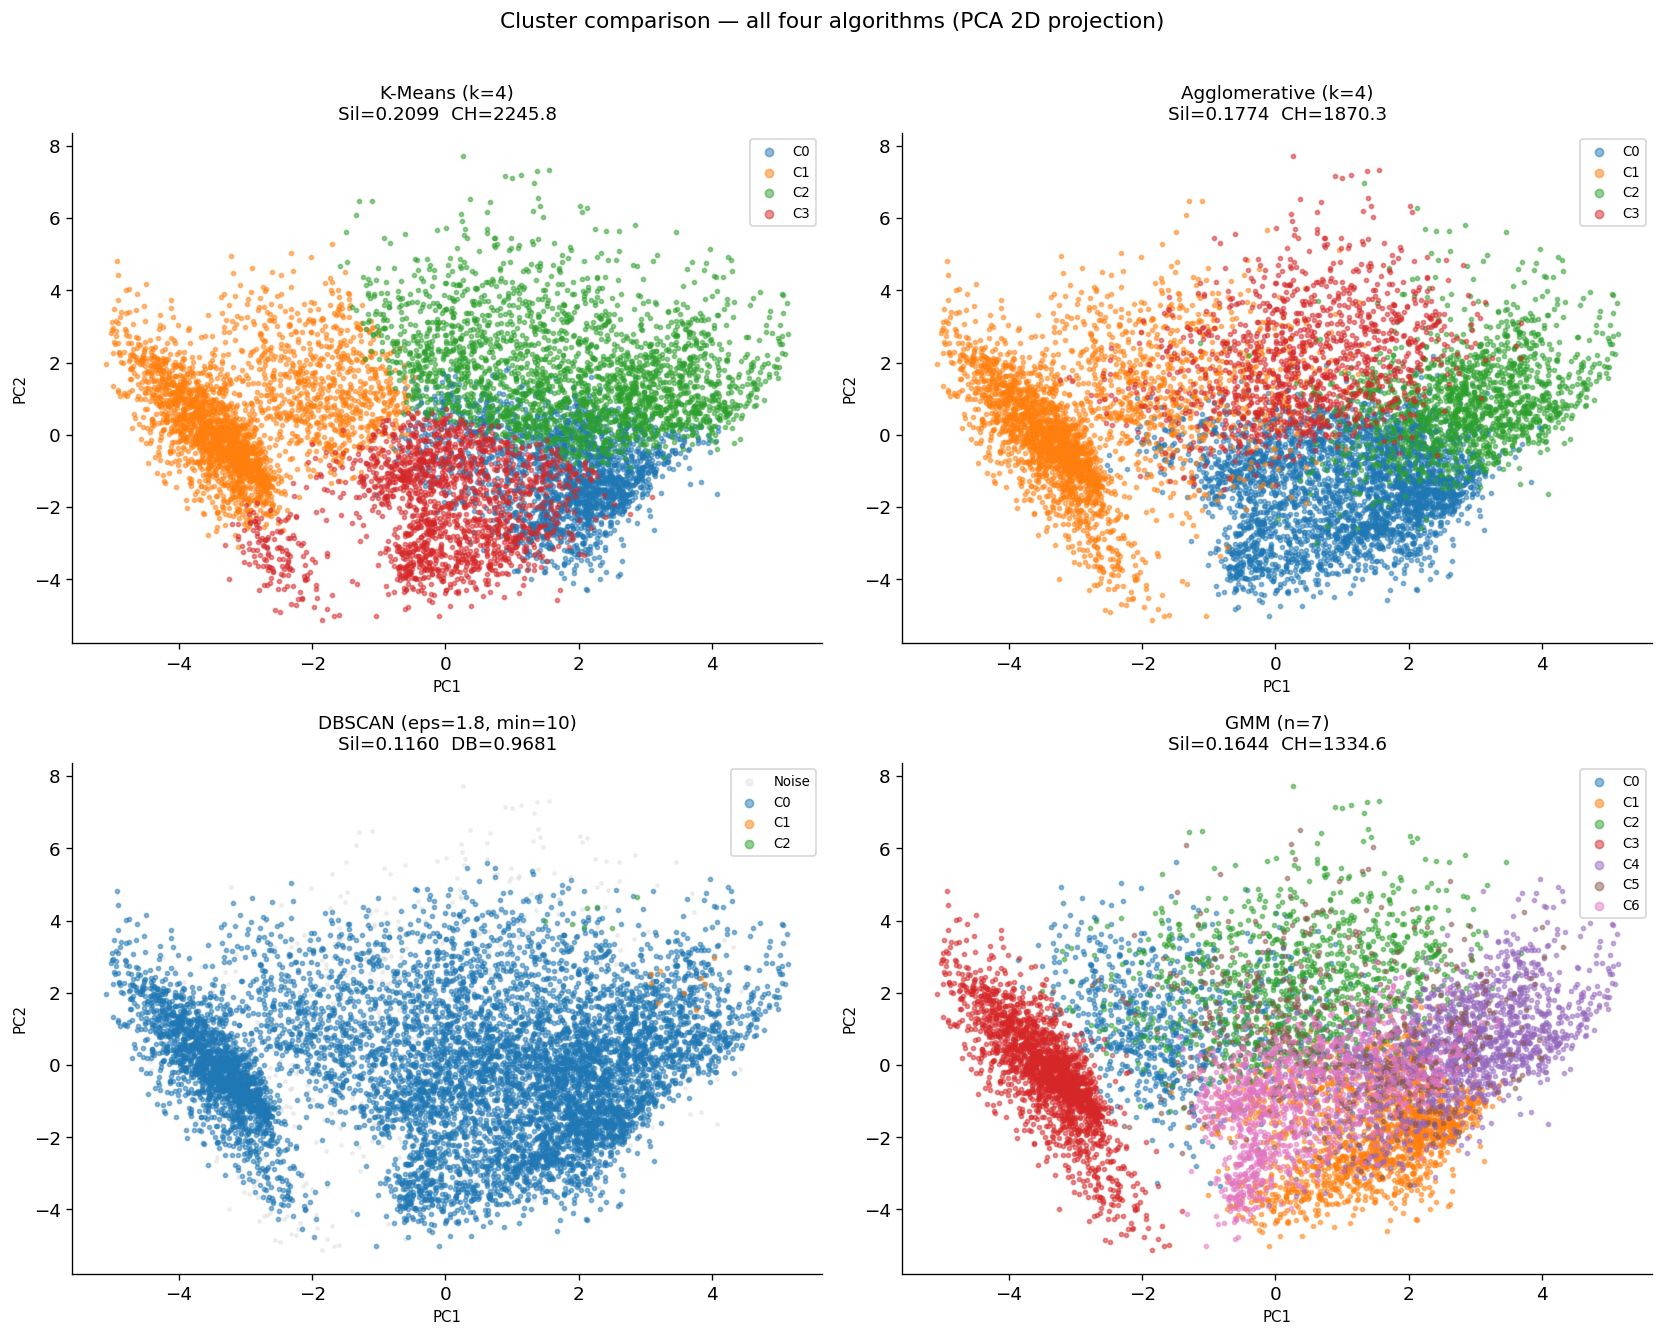

Saved: fig_all_models_comparison.png


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

configs = [
    (labels_kmeans,  'K-Means (k=4)\nSil=0.2099  CH=2245.8',   axes[0,0]),
    (labels_agglo,   'Agglomerative (k=4)\nSil=0.1774  CH=1870.3', axes[0,1]),
    (labels_dbscan,  'DBSCAN (eps=1.8, min=10)\nSil=0.1160  DB=0.9681', axes[1,0]),
    (labels_gmm,     'GMM (n=7)\nSil=0.1644  CH=1334.6',        axes[1,1]),
]

for labels, title, ax in configs:
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', n_colors=max(unique_labels) + 1)
    for label in unique_labels:
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c='lightgray', s=4, alpha=0.3, label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      color=palette[label], s=6, alpha=0.5,
                      label=f'C{label}')
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.legend(markerscale=2, fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Cluster comparison — all four algorithms (PCA 2D projection)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_all_models_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: fig_all_models_comparison.png')